In [1]:
import copy
import numpy as np
import pandas as pd
import torch

from torch import nn
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

print("torch :", torch.__version__)
print("cuda  :", torch.cuda.is_available())
print("device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")

torch : 2.13.0+cu132
cuda  : True
device: NVIDIA GeForce RTX 4090 Laptop GPU


In [2]:
# A batch is the number of training rows given to the autoencoder before it updates its weights.
# The bottleneck is the narrowest layer of the autoencoder.
# A very small bottleneck may lose important normal information.
# A very large bottleneck may allow the model to copy abnormal data too easily.
# The best size must therefore be determined experimentally.

batch = 1024
bottleneck = 16

# The shape and training of the model, held constant so that any difference
# in the results comes from batch and bottleneck and nothing else.
hidden = 64
epochs = 50
learning_rate = 0.001

# The same model trained five times from different random starting weights.
# The average is the result.
seeds = [0, 1, 2, 3, 4]

# This reserves 20% of the normal recordings for validation.
val_fraction = 0.2

# stop training if the validation loss has not improved for this many epochs
patience = 10

model_name = "vae"

# How hard the KL term pushes the latent clouds towards a standard bell curve.
# 1.0 is the standard variational autoencoder. 0 would remove the constraint
# entirely and give back a plain autoencoder. Values well above 1 risk posterior
# collapse, where the model ignores its input and the KL term falls to zero.
beta = 0.1

# Which sensor group has been removed.
removed_group = "A2_robot_health"

device = "cuda" if torch.cuda.is_available() else "cpu"

print("batch:", batch, " bottleneck:", bottleneck, " device:", device)

batch: 1024  bottleneck: 16  device: cuda


In [3]:
# The 94 features built in feature_engineering.ipynb, plus the run number.

train_data = pd.read_csv(r"C:\shared\LSBU\ablation-study-with-developed-hypertuned-models-for-anomaly-detection-in-hrc-robotics\train_dataset.csv")

print("rows   :", len(train_data))
print("columns:", train_data.shape[1])

rows   : 1556661
columns: 95


In [4]:
# The 80 labelled recording test data.

test_data = pd.read_csv(r"C:\shared\LSBU\ablation-study-with-developed-hypertuned-models-for-anomaly-detection-in-hrc-robotics\test_dataset.csv")

print("rows   :", len(test_data))
print("columns:", test_data.shape[1])
print()
print(test_data["anomaly_type"].value_counts())

rows   : 246151
columns: 97

anomaly_type
long_wait        47979
scale_speed      32804
push             31117
tcp_wrench       31062
change_weight    28978
force_stop       28438
outside_box      23499
drop_object      22274
Name: count, dtype: int64


In [5]:
# Every column except the run number is a feature the model will see.

feature_names = list(train_data.columns.drop("run_number"))

print("features:", len(feature_names))

features: 94


In [6]:
# A2 removes the robot's own health and electrical state: joint temperatures,
# joint voltages, and the machine-level power channels. None of these describe
# the task being performed; they describe the condition of the machine doing it.
#
# The diagnostic in Section X showed the joint temperatures rising twenty-one fold
# between the training and evaluation sessions while carrying no fault information,
# so this ablation is expected to improve detection.

removed_columns = []

for name in feature_names:
    if name.startswith("joint_temperatures"):
        removed_columns.append(name)
    if name.startswith("actual_joint_voltage"):
        removed_columns.append(name)

removed_columns.append("actual_main_voltage")
removed_columns.append("actual_robot_voltage")
removed_columns.append("actual_robot_current")

print("removing", len(removed_columns), "columns:")
for name in removed_columns:
    print("   ", name)

feature_names = [c for c in feature_names if c not in removed_columns]

print()
print("features remaining:", len(feature_names))

removing 15 columns:
    joint_temperatures_0
    joint_temperatures_1
    joint_temperatures_2
    joint_temperatures_3
    joint_temperatures_4
    joint_temperatures_5
    actual_joint_voltage_0
    actual_joint_voltage_1
    actual_joint_voltage_2
    actual_joint_voltage_3
    actual_joint_voltage_4
    actual_joint_voltage_5
    actual_main_voltage
    actual_robot_voltage
    actual_robot_current

features remaining: 79


In [7]:
# Split the dataset by complete robot recordings rather than individual rows.
# At 100 Hz, neighbouring rows are nearly identical. A row-level split could
# place almost identical readings in fitting and validation.

# Get each unique run number once and arrange the numbers in order.
all_runs = sorted(train_data["run_number"].unique())

# Randomly assign 80% of complete runs to fitting and 20% to validation.
# val_fraction sets the validation proportion. The parameter is called
# test_size because that is sklearn's generic name for the second group.
fit_runs, val_runs = train_test_split(
    all_runs,
    test_size=val_fraction,
    random_state=42
)

# Keep rows whose run_number appears in the existing fit_runs list.
# The @ tells Pandas that fit_runs is a Python variable outside the DataFrame.
fit_rows = train_data.query("run_number in @fit_runs")

# The same for the runs held back for validation.
val_rows = train_data.query("run_number in @val_runs")

# Display the number of complete runs and individual rows in each group.
print("fitting   :", len(fit_runs), "runs,", len(fit_rows), "rows")
print("validation:", len(val_runs), "runs,", len(val_rows), "rows")

fitting   : 488 runs, 1241647 rows
validation: 122 runs, 315014 rows


In [8]:
# scaling

scaler = StandardScaler()

# fit_transform LEARNS the mean and spread, then applies them. It is used on the
# fitting rows only. The other two get transform, which just applies what was
# already learned.
fit_scaled = scaler.fit_transform(fit_rows[feature_names])
val_scaled = scaler.transform(val_rows[feature_names])
test_scaled = scaler.transform(test_data[feature_names])

print("fit :", fit_scaled.shape)
print("val :", val_scaled.shape)
print("test:", test_scaled.shape)

fit : (1241647, 79)
val : (315014, 79)
test: (246151, 79)


In [9]:
# Copy the scaled data onto the GPU once, as 32-bit numbers. Keeping it there
# means training never has to fetch batches from main memory, which is what
# makes 60 training runs finish in hours.

fit_tensor = torch.tensor(fit_scaled, dtype=torch.float32, device=device)
val_tensor = torch.tensor(val_scaled, dtype=torch.float32, device=device)
test_tensor = torch.tensor(test_scaled, dtype=torch.float32, device=device)

# The labels stay on the CPU, because only scikit-learn reads them and it
# cannot see the GPU.
test_labels = test_data["label"].values
test_types = test_data["anomaly_type"].values

fault_names = sorted(test_data["anomaly_type"].unique())

print("fit :", fit_tensor.shape)
print("val :", val_tensor.shape)
print("test:", test_tensor.shape)
print("faults:", fault_names)

fit : torch.Size([1241647, 79])
val : torch.Size([315014, 79])
test: torch.Size([246151, 79])
faults: ['change_weight', 'drop_object', 'force_stop', 'long_wait', 'outside_box', 'push', 'scale_speed', 'tcp_wrench']


In [10]:
# The variational autoencoder. The encoder no longer produces a single point for
# each reading. It produces the centre and the width of a small cloud, and the
# decoder is given a random point drawn from that cloud.
#
# Only one thing differs from the plain autoencoder: the single layer that produced
# the 16 bottleneck values has become two parallel layers, one for the centres and
# one for the widths. That adds 1,040 weights, an increase of 8.4 per cent.

class VariationalAutoencoder(nn.Module):

    def __init__(self, n_features, hidden, bottleneck):

        super().__init__()

        # the shared part of the encoder, identical to the plain model
        self.encoder = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.ReLU(),
        )

        # two heads. one gives the centre of each cloud, the other its width.
        # the width is produced as a logarithm so the layer can output any number
        # and still describe a positive width once exponentiated.
        self.to_mean = nn.Linear(hidden, bottleneck)
        self.to_logspread = nn.Linear(hidden, bottleneck)

        # the decoder is unchanged from the plain autoencoder
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_features),
        )

    def forward(self, x, sample):

        h = self.encoder(x)

        mean = self.to_mean(h)
        log_spread = self.to_logspread(h)

        if sample:
            # take the logarithm back to an actual width
            spread = torch.exp(0.5 * log_spread)

            # draw a point from the cloud. the random number is generated outside
            # the network, so training can still work out how to adjust the centre
            # and the width. generating it inside would break backpropagation.
            z = mean + spread * torch.randn_like(spread)
        else:
            # when scoring, use the centre of the cloud. this makes the anomaly
            # score deterministic, so the same reading always scores the same.
            z = mean

        rebuilt = self.decoder(z)

        return rebuilt, mean, log_spread


example = VariationalAutoencoder(len(feature_names), hidden, bottleneck)
print(example)

total = 0
for p in example.parameters():
    total = total + p.numel()
print()
print("weights to learn:", total)

VariationalAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=79, out_features=64, bias=True)
    (1): ReLU()
  )
  (to_mean): Linear(in_features=64, out_features=16, bias=True)
  (to_logspread): Linear(in_features=64, out_features=16, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=79, bias=True)
  )
)

weights to learn: 13423


In [11]:
# One anomaly score per row, exactly as before. The only change is that the model
# now returns three things instead of one, and is asked not to sample, so the score
# is deterministic and directly comparable with every other run in the study.

def reconstruction_error(model, x):

    model.eval()

    with torch.no_grad():

        rebuilt, mean, log_spread = model(x, sample=False)

        squared_error = (rebuilt - x) ** 2

        # dim=1 averages across the features, leaving one number per row
        per_row = squared_error.mean(dim=1)

    return per_row.cpu().numpy()

In [12]:
# Train one variational autoencoder. The seed is the only thing that changes
# between the five runs; beta, batch, bottleneck and the rest come from the
# settings cell at the top.

def train_one_model(seed):

    # start the random numbers from the same place, so the run is repeatable
    torch.manual_seed(seed)

    model = VariationalAutoencoder(len(feature_names), hidden, bottleneck).to(device)

    optimiser = torch.optim.Adam(model.parameters(), lr=learning_rate)

    n_rows = fit_tensor.shape[0]

    best_val = float("inf")
    best_epoch = 0
    best_weights = None
    waited = 0
    val_curve = []

    for epoch in range(epochs):

        model.train()

        order = torch.randperm(n_rows, device=device)

        # running totals, so the two parts of the loss can be watched separately
        recon_total = 0.0
        kl_total = 0.0
        n_batches = 0

        for start in range(0, n_rows, batch):

            rows = fit_tensor[order[start:start + batch]]

            # sample=True, so the decoder receives a random point from each cloud
            rebuilt, mean, log_spread = model(rows, sample=True)

            # part one: how badly the reading was rebuilt. the squared errors are
            # added across the 79 features, then averaged across the rows. Adding
            # rather than averaging is what puts this term on the same scale as
            # the KL term below, so that beta = 1 means what it is supposed to.
            recon = ((rebuilt - rows) ** 2).sum(dim=1).mean()

            # part two: how far each cloud has drifted from a standard bell curve
            # centred on zero with width one. this is the exact closed form of the
            # KL divergence for a diagonal Gaussian against a standard normal, so
            # no sampling or approximation is needed to compute it.
            kl_per_row = -0.5 * (1 + log_spread - mean ** 2 - log_spread.exp()).sum(dim=1)
            kl = kl_per_row.mean()

            # the two jobs pull against each other. beta sets the balance between
            # rebuilding accurately and keeping the clouds near the reference.
            loss = recon + beta * kl

            optimiser.zero_grad()
            loss.backward()
            optimiser.step()

            recon_total = recon_total + recon.item()
            kl_total = kl_total + kl.item()
            n_batches = n_batches + 1

        # measured with sampling switched off, so this is comparable with every
        # other model in the study
        val_loss = float(reconstruction_error(model, val_tensor).mean())
        val_curve.append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_epoch = epoch + 1
            best_weights = copy.deepcopy(model.state_dict())
            waited = 0
        else:
            waited = waited + 1

        # both parts of the loss are printed. if KL collapses towards zero while
        # the reconstruction stays poor, the model has stopped reading its input
        # and that run is not a valid test of a variational autoencoder.
        if (epoch + 1) % 10 == 0:
            print("      epoch", epoch + 1, "of", epochs,
                  "  recon", round(recon_total / n_batches, 4),
                  "  KL", round(kl_total / n_batches, 4),
                  "  val", round(val_loss, 6))

        if waited >= patience:
            print("      stopped early at epoch", epoch + 1, "- best was epoch", best_epoch)
            break

    # Put the best weights back. Without this the model keeps whatever the final
    # epoch produced, which is not the model that was selected.
    model.load_state_dict(best_weights)

    fit_loss = reconstruction_error(model, fit_tensor).mean()

    return model, float(fit_loss), val_curve, best_epoch

In [13]:
# Train the same model five times, once per seed. From each one we keep two
# things: a note of how well it trained, and its score for every test row.

model_notes = []
model_errors = []

for seed in seeds:

    print("seed", seed)

    model, fit_loss, val_curve, best_epoch = train_one_model(seed)

    # The restored weights come from best_epoch, not from the last epoch, so the
    # validation loss to report is the best one - not val_curve[-1]. Taking the
    # last one would describe a model that was thrown away.
    val_loss = min(val_curve)

    # one anomaly score for each of the 246,151 test rows
    errors = reconstruction_error(model, test_tensor)

    # how much worse the model does on normal data it has never seen than on the
    # data it trained on. a big gap means the test session drifted away from the
    # training session, which validation loss on its own cannot reveal.
    normal_error = float(errors[test_labels == 0].mean())

    print("   best epoch :", best_epoch, "of", len(val_curve))
    print("   fit loss   :", round(fit_loss, 6))
    print("   val loss   :", round(val_loss, 6))
    print("   test normal:", round(normal_error, 6))
    print("   ratio      :", round(normal_error / fit_loss, 2))

    model_notes.append({
        "seed": seed,
        "best_epoch": best_epoch,
        "epochs_run": len(val_curve),
        "fit_loss": fit_loss,
        "val_loss": val_loss,
        "test_normal_error": normal_error,
        "ratio": normal_error / fit_loss,
        "val_curve": val_curve,
    })

    model_errors.append(errors)

print()
print("trained", len(model_errors), "models")

seed 0
      epoch 10 of 50   recon 2.3639   KL 32.9751   val 0.020019
      epoch 20 of 50   recon 2.1393   KL 31.6128   val 0.017195
      epoch 30 of 50   recon 2.0437   KL 30.8531   val 0.016168
      epoch 40 of 50   recon 1.9902   KL 30.2975   val 0.015863
      epoch 50 of 50   recon 1.9556   KL 29.9858   val 0.01524
   best epoch : 50 of 50
   fit loss   : 0.01513
   val loss   : 0.01524
   test normal: 0.022642
   ratio      : 1.5
seed 1
      epoch 10 of 50   recon 2.3186   KL 32.9897   val 0.019704
      epoch 20 of 50   recon 2.1328   KL 31.9211   val 0.017443
      epoch 30 of 50   recon 2.0533   KL 31.2413   val 0.016575
      epoch 40 of 50   recon 2.0054   KL 30.7899   val 0.016283
      epoch 50 of 50   recon 1.9707   KL 30.4664   val 0.015656
   best epoch : 49 of 50
   fit loss   : 0.015345
   val loss   : 0.015542
   test normal: 0.022667
   ratio      : 1.48
seed 2
      epoch 10 of 50   recon 2.3334   KL 33.0538   val 0.019462
      epoch 20 of 50   recon 2.1151  

In [14]:
# Score each of the five models against each of the eight fault types.
records = []

# go through the five trained models using positions 0, 1, 2, 3 and 4.
for i in range(len(seeds)):

    # get the seed belonging to this model.
    seed = seeds[i]

    # get all test-row anomaly scores produced by this model.
    errors = model_errors[i]


    # evaluate this model separately on each of the eight fault types.
    for fault in fault_names:

        # mark rows belonging to the current fault as True.
        belongs = (test_types == fault)

        # calculate and save this model's results for this fault.
        records.append({
            "batch": batch,
            "bottleneck": bottleneck,
            "seed": seed,
            "anomaly_type": fault,
            "roc_auc": roc_auc_score(test_labels[belongs], errors[belongs]),
            "pr_auc": average_precision_score(test_labels[belongs], errors[belongs]),
            "contamination": test_labels[belongs].mean(),
        })

# convert the collected result records into a Pandas table.
results = pd.DataFrame(records)

# five models multiplied by eight faults should produce 40 rows.
print(len(results), "rows")

40 rows


In [15]:
# The result for this configuration.
# the average across the five seeds for every fault, with the spread beside it. The average is the finding.

print("batch", batch, " bottleneck", bottleneck, " averaged over", len(seeds), "seeds")
print()

# calculate a separate summary for each anomaly type.
for fault in fault_names:

    # keep the five result rows belonging to this fault.
    # one result from each random seed.
    rows = results[results["anomaly_type"] == fault]

     # calculate the average ROC-AUC across the five models.
    roc_mean = rows["roc_auc"].mean()
    # measure how much ROC-AUC changed between the five models.
    roc_spread = rows["roc_auc"].std()
    # calculate the average PR-AUC across the five models.
    pr_mean = rows["pr_auc"].mean()
    # measure how much PR-AUC changed between the five models.
    pr_spread = rows["pr_auc"].std()

    # A model guessing at random scores 0.5 on ROC-AUC but scores the
    # contamination rate on PR-AUC. So PR-AUC needs its own floor printed
    # beside it, otherwise the numbers are easy to misread.
    floor = rows["contamination"].mean()

    print(fault)
    print("   ROC-AUC", round(roc_mean, 4), "+/-", round(roc_spread, 4))
    print("   PR-AUC ", round(pr_mean, 4), "+/-", round(pr_spread, 4), "  chance is", round(floor, 4))

 # calculate the overall macro-average across all faults and seeds.
print()
print("MEAN ACROSS THE EIGHT FAULTS")
print("   ROC-AUC", round(results["roc_auc"].mean(), 4))
print("   PR-AUC ", round(results["pr_auc"].mean(), 4))

batch 1024  bottleneck 16  averaged over 5 seeds

change_weight
   ROC-AUC 0.7832 +/- 0.0171
   PR-AUC  0.6003 +/- 0.0271   chance is 0.3332
drop_object
   ROC-AUC 0.932 +/- 0.0028
   PR-AUC  0.8014 +/- 0.0096   chance is 0.2292
force_stop
   ROC-AUC 0.7559 +/- 0.0353
   PR-AUC  0.2531 +/- 0.0394   chance is 0.1404
long_wait
   ROC-AUC 0.9781 +/- 0.0117
   PR-AUC  0.874 +/- 0.0365   chance is 0.1167
outside_box
   ROC-AUC 0.9267 +/- 0.0045
   PR-AUC  0.7269 +/- 0.0217   chance is 0.3208
push
   ROC-AUC 0.8754 +/- 0.0072
   PR-AUC  0.4045 +/- 0.0114   chance is 0.0864
scale_speed
   ROC-AUC 0.846 +/- 0.0187
   PR-AUC  0.6267 +/- 0.0303   chance is 0.2271
tcp_wrench
   ROC-AUC 0.974 +/- 0.0134
   PR-AUC  0.9099 +/- 0.0245   chance is 0.15

MEAN ACROSS THE EIGHT FAULTS
   ROC-AUC 0.8839
   PR-AUC  0.6496


In [16]:
# Everything from this configuration written to its own folder, so the next
# configuration cannot overwrite it.

folder = r"C:\shared\LSBU\ablation-study-with-developed-hypertuned-models-for-anomaly-detection-in-hrc-robotics\results_ablation\\" + model_name + "_beta" + str(int(beta * 100)) + "_" + removed_group + "_f" + str(len(feature_names)) + "_bs" + str(batch) + "_bn" + str(bottleneck)

Path(folder).mkdir(parents=True, exist_ok=True)

# the 40 scored rows: five seeds by eight faults
results.to_csv(folder + r"\results.csv", index=False)

# one row per model. the curve is left out because a list does not fit in a cell.
notes_table = pd.DataFrame(model_notes).drop(columns=["val_curve"])
notes_table.to_csv(folder + r"\notes.csv", index=False)

# the validation curves, one row per epoch per seed. early stopping can end
# different seeds at different epochs, so they are stored long rather than side by side.
curve_records = [] # this list collects every validation-loss measurement.

for note in model_notes:
    # for each seed, it retrieves its validation-loss history.
    curve = note["val_curve"] 

    for i in range(len(curve)): # it visits every recorded epochs
        curve_records.append({
            "seed": note["seed"],
            "epoch": i + 1,
            "val_loss": curve[i],
        })

pd.DataFrame(curve_records).to_csv(folder + r"\val_curves.csv", index=False)

# The raw anomaly scores: 5 seeds x 246,151 test rows. Saving these means any
# figure can be redrawn later without training anything again.
np.save(folder + r"\test_errors.npy", np.array(model_errors, dtype="float32"))

# A plain record of what was actually run, written from the variables themselves.
settings = open(folder + r"\settings.txt", "w")
settings.write("features      : " + str(len(feature_names)) + "\n")
settings.write("batch size    : " + str(batch) + "\n")
settings.write("bottleneck    : " + str(bottleneck) + "\n")
settings.write("hidden layer  : " + str(hidden) + "\n")
settings.write("max epochs    : " + str(epochs) + "\n")
settings.write("patience      : " + str(patience) + "\n")
settings.write("learning rate : " + str(learning_rate) + "\n")
settings.write("seeds         : " + str(seeds) + "\n")
settings.write("val fraction  : " + str(val_fraction) + "\n")
settings.write("model         : " + model_name + "\n")
settings.write("beta          : " + str(beta) + "\n")
settings.write("removed group : " + removed_group + "\n")
settings.write("mean ROC-AUC  : " + str(round(results["roc_auc"].mean(), 4)) + "\n")
settings.write("mean PR-AUC   : " + str(round(results["pr_auc"].mean(), 4)) + "\n")
settings.close()

print("saved to", folder)
print()
print(notes_table)

saved to C:\shared\LSBU\ablation-study-with-developed-hypertuned-models-for-anomaly-detection-in-hrc-robotics\results_ablation\\vae_beta10_A2_robot_health_f79_bs1024_bn16

   seed  best_epoch  epochs_run  fit_loss  val_loss  test_normal_error  \
0     0          50          50  0.015130  0.015240           0.022642   
1     1          49          50  0.015345  0.015542           0.022667   
2     2          49          50  0.014994  0.015138           0.022203   
3     3          50          50  0.015600  0.015773           0.023082   
4     4          45          50  0.014464  0.014587           0.021539   

      ratio  
0  1.496571  
1  1.477140  
2  1.480765  
3  1.479562  
4  1.489136  


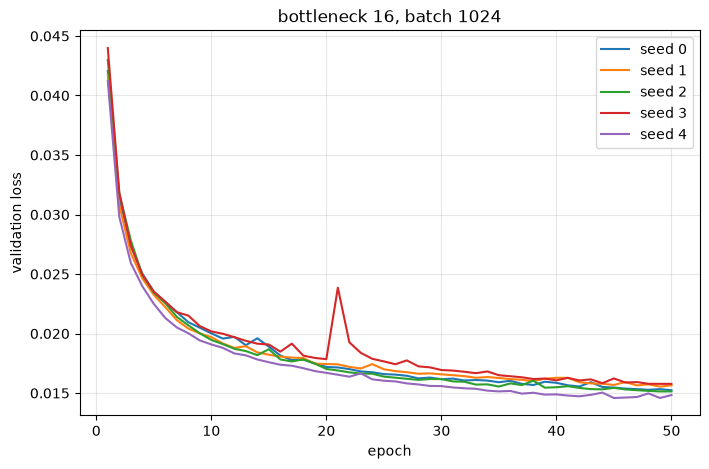

In [17]:
# validation curves
# create an empty graph that is 8 inches wide and 5 inches high.
plt.figure(figsize=(8, 5))

# draw one validation-loss line for each trained model.
for note in model_notes:
    # get all validation-loss values recorded for this model.
    curve = note["val_curve"]
    # create epoch numbers starting from 1.
    epoch_numbers = range(1, len(curve) + 1)

    # plot this model's validation loss against its epoch numbers.
    plt.plot(epoch_numbers, curve, label="seed " + str(note["seed"]))

# name the horizontal and vertical axes.
plt.xlabel("epoch")
plt.ylabel("validation loss")

# show the current bottleneck and batch size in the graph title.
plt.title("bottleneck " + str(bottleneck) + ", batch " + str(batch))
# show which graph line belongs to each seed.
plt.legend()
# add a light background grid to make values easier to read.
plt.grid(alpha=0.3)
# save the completed graph inside this configuration's results folder.
plt.savefig(folder + r"\val_curves.png", dpi=150, bbox_inches="tight")
# display the graph in the notebook.
plt.show()

change_weight    table: 0.7832   curve: 0.7832
drop_object      table: 0.932   curve: 0.932
force_stop       table: 0.7559   curve: 0.7559
long_wait        table: 0.9781   curve: 0.978
outside_box      table: 0.9267   curve: 0.9267
push             table: 0.8754   curve: 0.8754
scale_speed      table: 0.846   curve: 0.846
tcp_wrench       table: 0.974   curve: 0.9739


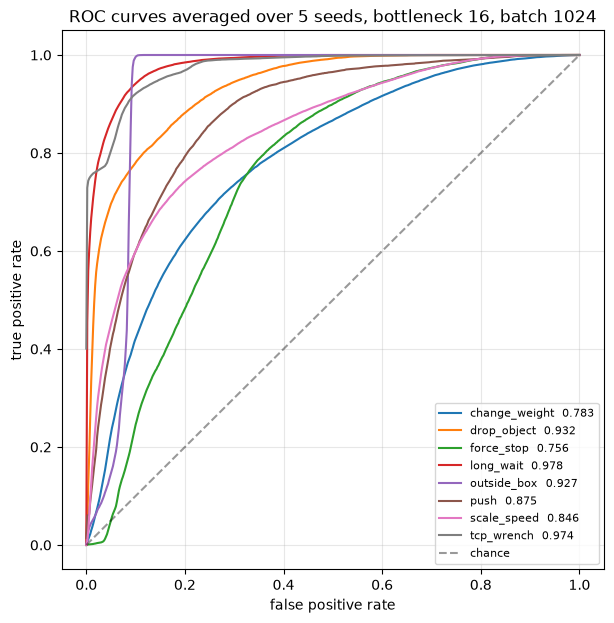

In [18]:
# ROC curves
#  One curve per fault averaged across all five seeds.
# Each seed produces its own curve, they are read off at the same shared positions, and then averaged.
# This is vertical averaging, the standard way of averaging ROC curves. The area under
# the averaged curve equals the average of the five areas.

# 500 evenly spaced false positive rates from 0 to 1
common_fpr = np.linspace(0, 1, 500)

# creae an empty square graph
plt.figure(figsize=(7, 7))


# draw one averaged ROC curve for each anomaly type.
for fault in fault_names:

    # select only test rows belonging to the current fault.
    belongs = (test_types == fault)

    # store this fault's ROC curve from each of the five models. 
    curves = []

    # process the anomaly scores from each seed/model.
    for errors in model_errors:

        # alculate this model's ROC curve for the current fault.
        false_positive_rate, true_positive_rate, thresholds = roc_curve(test_labels[belongs], errors[belongs])

        # read this seed's curve off at the 500 shared positions, so all five
        # curves have their points in the same places and can be averaged
        curves.append(np.interp(common_fpr, false_positive_rate, true_positive_rate))
    
    # convert the five stored curves into a NumPy array.
    # its shape will be: 5 models × 500 curve positions.
    curves = np.array(curves)

    # average the five models at every curve position.
    # this leaves one mean ROC curve containing 500 points.
    mean_curve = curves.mean(axis=0)

    # the same averaged score already in the results table
    score = results[results["anomaly_type"] == fault]["roc_auc"].mean()

    # checking the area under the averaged curve must equal the averaged score from
    # the table. Vertical averaging has this property.
    area = np.trapezoid(mean_curve, common_fpr)
    print(fault.ljust(16), "table:", round(score, 4), "  curve:", round(area, 4))

    # draw this fault's averaged ROC curve.
    plt.plot(common_fpr, mean_curve, label=fault + "  " + str(round(score, 3)))

# draw the diagonal representing random performance.
plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="chance")

# Add graph labels and formatting.
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("ROC curves averaged over 5 seeds, bottleneck " + str(bottleneck) + ", batch " + str(batch))
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)

# saving
plt.savefig(folder + r"\roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

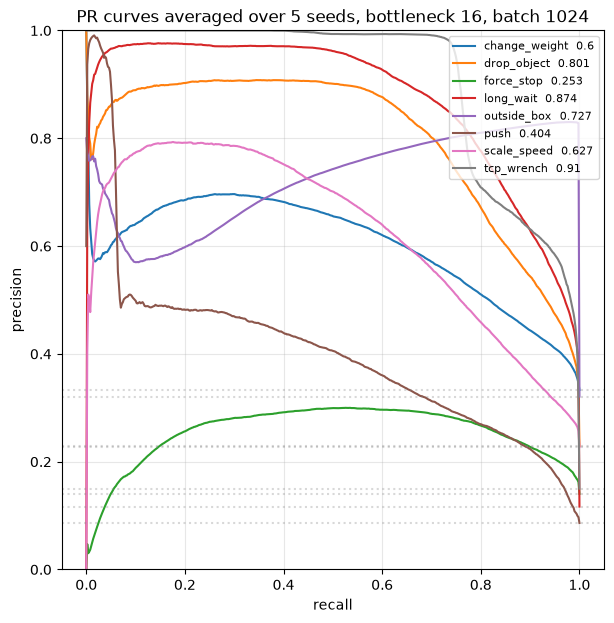

In [19]:
# PR curves, one per fault, averaged across the five seeds the same way the ROC
# curves were. The dashed line for each fault is what random guessing would score,
# which for PR-AUC is that fault's contamination rate rather than 0.5.

# the shared x axis: 500 evenly spaced recall values from 0 to 1
common_recall = np.linspace(0, 1, 500)

plt.figure(figsize=(7, 7))

for fault in fault_names:

    belongs = (test_types == fault)

    curves = []

    for errors in model_errors:

        precision, recall, thresholds = precision_recall_curve(test_labels[belongs], errors[belongs])

        # precision_recall_curve hands recall back running downwards, and np.interp
        # needs its x values to run upwards, so both are reversed first
        curves.append(np.interp(common_recall, recall[::-1], precision[::-1]))

    curves = np.array(curves)

    mean_curve = curves.mean(axis=0)

    score = results[results["anomaly_type"] == fault]["pr_auc"].mean()

    plt.plot(common_recall, mean_curve, label=fault + "  " + str(round(score, 3)))

# each fault has its own chance level, so draw one faint line per fault
for fault in fault_names:
    floor = results[results["anomaly_type"] == fault]["contamination"].mean()
    plt.axhline(floor, color="grey", linestyle=":", alpha=0.3)

plt.xlabel("recall")
plt.ylabel("precision")
plt.ylim(0, 1)
plt.title("PR curves averaged over 5 seeds, bottleneck " + str(bottleneck) + ", batch " + str(batch))
plt.legend(loc="upper right", fontsize=8)
plt.grid(alpha=0.3)

plt.savefig(folder + r"\pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()